# Autoencoder (AE), Variational Autoencoder (VAE), and VAEGAN with Pythae

This notebook trains AE, VAE, and VAEGAN models using [Pythae documentation](https://pythae.readthedocs.io/en/latest/models/pythae.models.html) on the online FashionMNIST image dataset.

In [1]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt

from torchvision.datasets import FashionMNIST
from torchvision import transforms

from pythae.models import AE, AEConfig, VAE, VAEConfig, VAEGAN, VAEGANConfig
from pythae.trainers import BaseTrainerConfig, CoupledOptimizerAdversarialTrainerConfig
from pythae.pipelines import TrainingPipeline

/home/sces55/Malaika/extras/litlab/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


/home/sces55/Malaika/extras/litlab/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
torch.cuda.is_available()

False

In [4]:
# Download FashionMNIST (online dataset)
transform = transforms.ToTensor()
train_ds = FashionMNIST(root="./data", train=True, transform=transform, download=True)
test_ds = FashionMNIST(root="./data", train=False, transform=transform, download=True)

# Keep a manageable subset so this notebook is fast to run
n_train = 20000
n_eval = 5000

train_data = torch.stack([train_ds[i][0] for i in range(n_train)])
eval_data = torch.stack([test_ds[i][0] for i in range(n_eval)])

print("Train shape:", train_data.shape)
print("Eval shape :", eval_data.shape)

Train shape: torch.Size([20000, 1, 28, 28])
Eval shape : torch.Size([5000, 1, 28, 28])


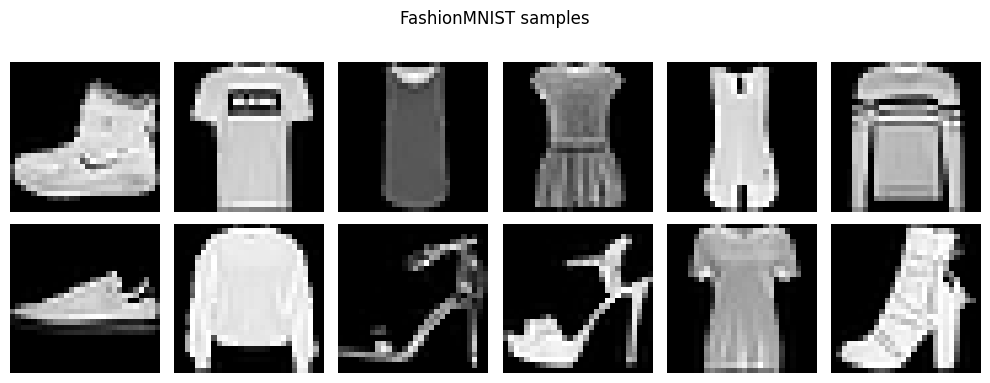

In [5]:
# Quick dataset preview
fig, axes = plt.subplots(2, 6, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(train_data[i].squeeze(0), cmap="gray")
    ax.axis("off")
plt.suptitle("FashionMNIST samples")
plt.tight_layout()
plt.show()

In [ ]:
def train_model(model_name: str, latent_dim: int = 16, num_epochs: int = 100):
    model_key = model_name.lower()

    if model_key == "ae":
        model_config = AEConfig(input_dim=(1, 28, 28), latent_dim=latent_dim)
        model = AE(model_config=model_config)
        training_config = BaseTrainerConfig(
            output_dir=f"outputs/{model_key}_fashionmnist",
            num_epochs=num_epochs,
            learning_rate=1e-3,
            per_device_train_batch_size=256,
            per_device_eval_batch_size=256,
            steps_saving=None
        )
    elif model_key == "vae":
        model_config = VAEConfig(input_dim=(1, 28, 28), latent_dim=latent_dim)
        model = VAE(model_config=model_config)
        training_config = BaseTrainerConfig(
            output_dir=f"outputs/{model_key}_fashionmnist",
            num_epochs=num_epochs,
            learning_rate=1e-3,
            per_device_train_batch_size=256,
            per_device_eval_batch_size=256,
            steps_saving=None
        )
    elif model_key == "vaegan":
        model_config = VAEGANConfig(
            input_dim=(1, 28, 28),
            latent_dim=latent_dim,
            adversarial_loss_scale=0.2,
            margin=0.4,
            equilibrium=0.5
        )
        model = VAEGAN(model_config=model_config)
        training_config = CoupledOptimizerAdversarialTrainerConfig(
            output_dir=f"outputs/{model_key}_fashionmnist",
            num_epochs=num_epochs,
            learning_rate=1e-4,
            per_device_train_batch_size=64,
            per_device_eval_batch_size=64,
            steps_saving=None
        )
    else:
        raise ValueError("model_name must be either 'ae', 'vae', or 'vaegan'")

    pipeline = TrainingPipeline(training_config=training_config, model=model)
    pipeline(train_data=train_data, eval_data=eval_data)
    return model

def plot_reconstructions(model, data, n=8, title="Reconstructions"):
    model.eval()
    with torch.no_grad():
        x = data[:n]
        x_hat = model.reconstruct(x)

    fig, axes = plt.subplots(2, n, figsize=(2*n, 4))
    for i in range(n):
        axes[0, i].imshow(x[i].squeeze(0).cpu(), cmap="gray")
        axes[0, i].axis("off")
        axes[0, i].set_title("Original")

        axes[1, i].imshow(x_hat[i].squeeze(0).cpu(), cmap="gray")
        axes[1, i].axis("off")
        axes[1, i].set_title("Recon")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def reconstruction_mse(model, data, n=1000):
    model.eval()
    with torch.no_grad():
        x = data[:n]
        x_hat = model.reconstruct(x)
        return torch.mean((x - x_hat) ** 2).item()

Preprocessing train data...
Checking train dataset...
Preprocessing eval data...

Checking eval dataset...
Using Base Trainer

Model passed sanity check !
Ready for training.

Created outputs/ae_fashionmnist/AE_training_2026-04-07_13-02-41. 
Training config, checkpoints and final model will be saved here.

Training params:
 - max_epochs: 8
 - per_device_train_batch_size: 256
 - per_device_eval_batch_size: 256
 - checkpoint saving every: None
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Scheduler: None

Successfully launched training !

Eval of epoch 1/8: 100%|██████████| 20/20 [00:00<00:00, 226.18batch/s]
--------------------------------------------------------------------------
Train loss: 45.4933
Eval loss: 22.725
-----------------------------------------------------

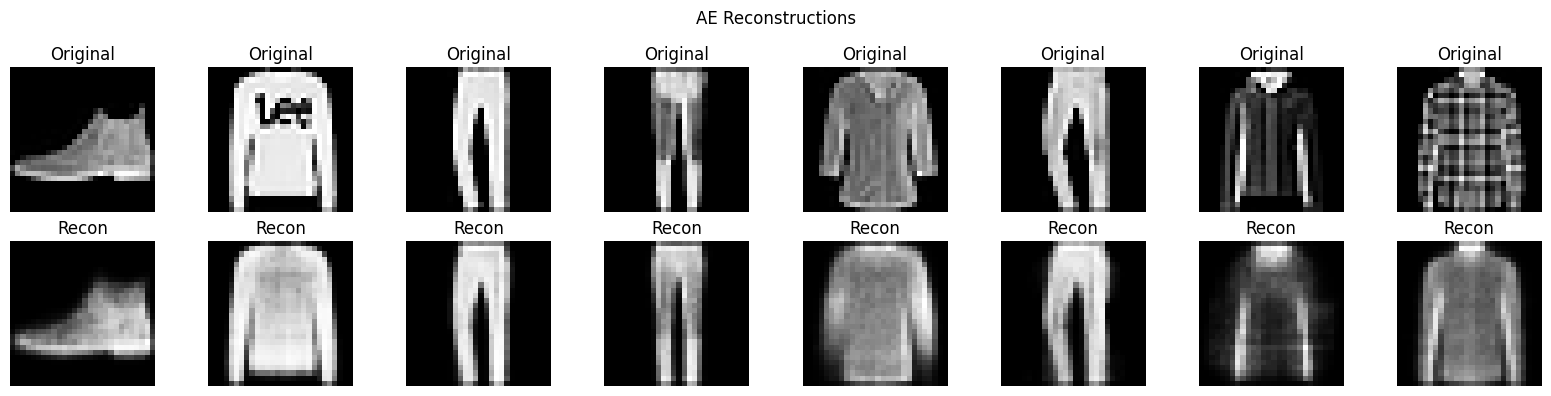

AE reconstruction MSE: 0.014476608484983444


In [7]:
ae_model = train_model("ae", latent_dim=16, num_epochs=8)
plot_reconstructions(ae_model, eval_data, n=8, title="AE Reconstructions")
print("AE reconstruction MSE:", reconstruction_mse(ae_model, eval_data))

Preprocessing train data...
Checking train dataset...
Preprocessing eval data...

Checking eval dataset...
Using Base Trainer

Model passed sanity check !
Ready for training.

Created outputs/vae_fashionmnist/VAE_training_2026-04-07_13-02-52. 
Training config, checkpoints and final model will be saved here.

Training params:
 - max_epochs: 8
 - per_device_train_batch_size: 256
 - per_device_eval_batch_size: 256
 - checkpoint saving every: None
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Scheduler: None

Successfully launched training !

Eval of epoch 1/8: 100%|██████████| 20/20 [00:00<00:00, 209.80batch/s]
--------------------------------------------------------------------------
Train loss: 31.0157
Eval loss: 23.658
---------------------------------------------------

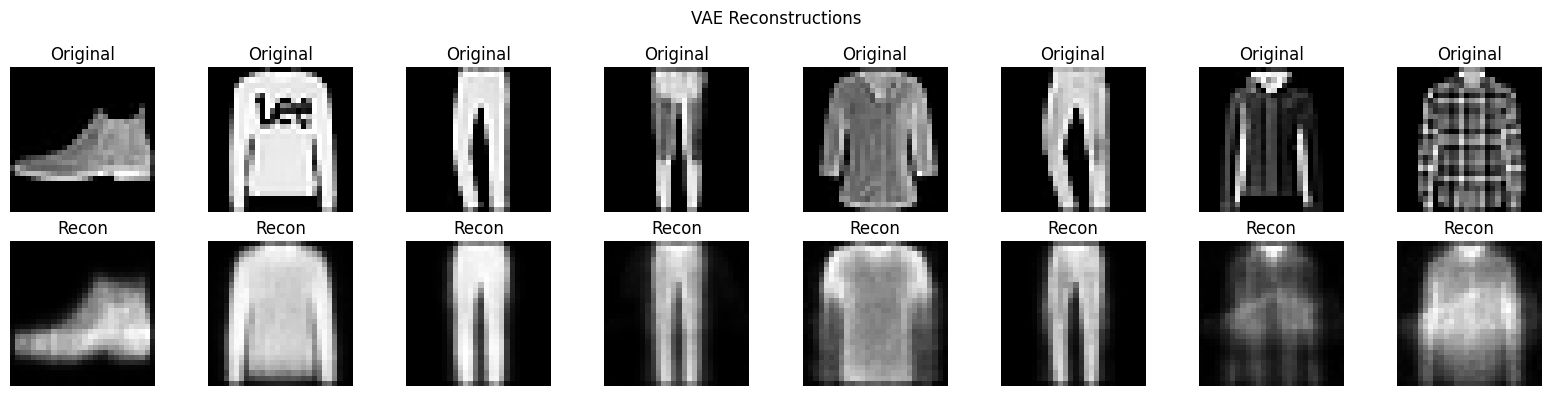

VAE reconstruction MSE: 0.031734321266412735


In [8]:
vae_model = train_model("vae", latent_dim=16, num_epochs=8)
plot_reconstructions(vae_model, eval_data, n=8, title="VAE Reconstructions")
print("VAE reconstruction MSE:", reconstruction_mse(vae_model, eval_data))

Preprocessing train data...
Checking train dataset...
Preprocessing eval data...

Checking eval dataset...
Using Coupled Optimizer Adversarial Trainer

Model passed sanity check !
Ready for training.

Created outputs/vaegan_fashionmnist/VAEGAN_training_2026-04-07_13-03-04. 
Training config, checkpoints and final model will be saved here.

Training params:
 - max_epochs: 8
 - per_device_train_batch_size: 64
 - per_device_eval_batch_size: 64
 - checkpoint saving every: None
Encoder Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
Encoder Scheduler: None
Decoder Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr

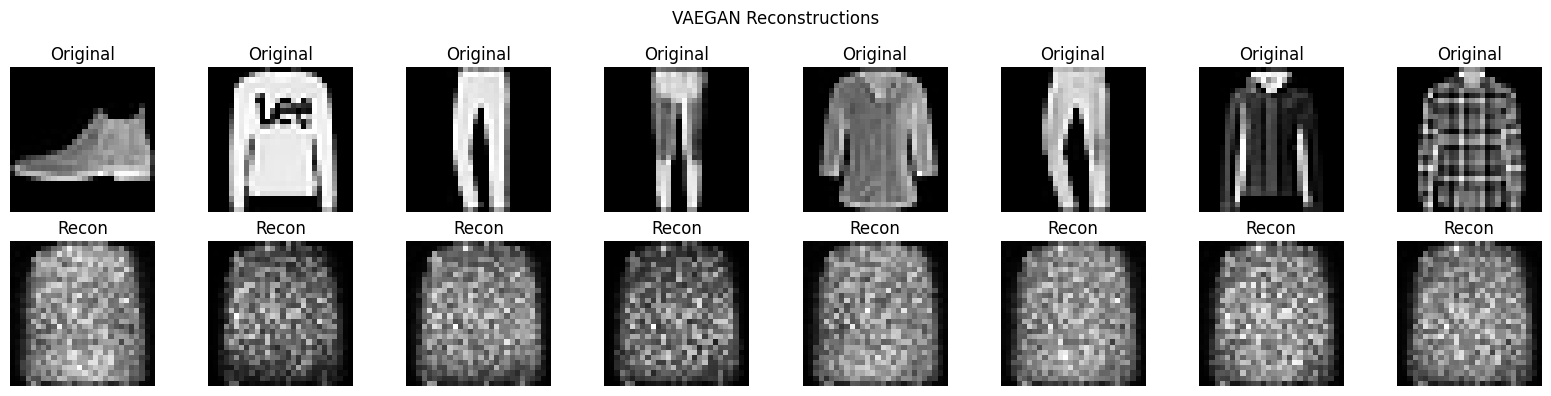

VAEGAN reconstruction MSE: 0.10478419065475464


In [9]:
vaegan_model = train_model("vaegan", latent_dim=16, num_epochs=8)
plot_reconstructions(vaegan_model, eval_data, n=8, title="VAEGAN Reconstructions")
print("VAEGAN reconstruction MSE:", reconstruction_mse(vaegan_model, eval_data))